# MNIST: Embedded Interpolants

1. Per-digit generation (fit on one class, generate fresh)
2. **Unconditional**: single model on all digits, sample noise → get random digit

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import sys
sys.path.insert(0, '..')
from src import EmbeddedInterpolants, sliced_wasserstein1

np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 140

In [3]:
digits = load_digits()
X_all = digits.data / 16.0
y_all = digits.target
print(f'Dataset: {X_all.shape}')

Dataset: (1797, 64)


In [4]:
def show_digits(images, n=10, title='', ax=None):
    if ax is None: fig,ax=plt.subplots(1,1,figsize=(n*1.2,1.5))
    strip=np.ones((8,9*n-1))*0.5
    for i in range(min(n,len(images))): strip[:,i*9:i*9+8]=np.clip(images[i].reshape(8,8),0,1)
    ax.imshow(strip,cmap='gray_r',interpolation='nearest',aspect='auto',vmin=0,vmax=1)
    ax.set_title(title,fontweight='bold',fontsize=10); ax.set_xticks([]);ax.set_yticks([])
    return ax

---
## 1. Per-digit generation (all 10 digits)

In [27]:
d_pca = 40
results = {}

for digit in range(10):
    mask = y_all == digit
    X_d = X_all[mask]
    pca = PCA(n_components=d_pca)
    X_pca = pca.fit_transform(X_d)
    scale = np.maximum(np.std(X_pca, axis=0, keepdims=True), 1e-3)
    X_pca_n = X_pca / scale
    idx = np.random.permutation(len(X_d))
    n_train = int(0.8 * len(X_d))
    X_train = X_pca_n[idx[:n_train]]
    X_test  = X_pca_n[idx[n_train:]]

    n_src  = 500
    n_test = 500

    model = EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-8, K_steps=80, n_inducing=100, q=0.5, q_final=0.1)
    model.fit(np.random.randn(n_src, d_pca), X_train,
              n_iterations=3, verbose=False)
    res = model.transport(np.random.randn(n_test, d_pca))
    sw = sliced_wasserstein1(res['particles'], X_test)

    results[digit] = {
        'sw': sw,
        'model': model,
        'res': res,
        'pca': pca,
        'scale': scale,
        'real': X_d[idx[:50]],
        'train_pixels': np.clip(pca.inverse_transform(
            model._fit_result['particles'] * scale), 0, 1),
        'fresh_pixels': np.clip(pca.inverse_transform(
            res['particles'] * scale), 0, 1),
    }
    print(f"Digit {digit}: SW1={sw:.3f}")

Digit 0: SW1=0.232
Digit 1: SW1=0.225
Digit 2: SW1=0.223
Digit 3: SW1=0.259
Digit 4: SW1=0.214
Digit 5: SW1=0.245
Digit 6: SW1=0.246
Digit 7: SW1=0.258
Digit 8: SW1=0.271
Digit 9: SW1=0.251


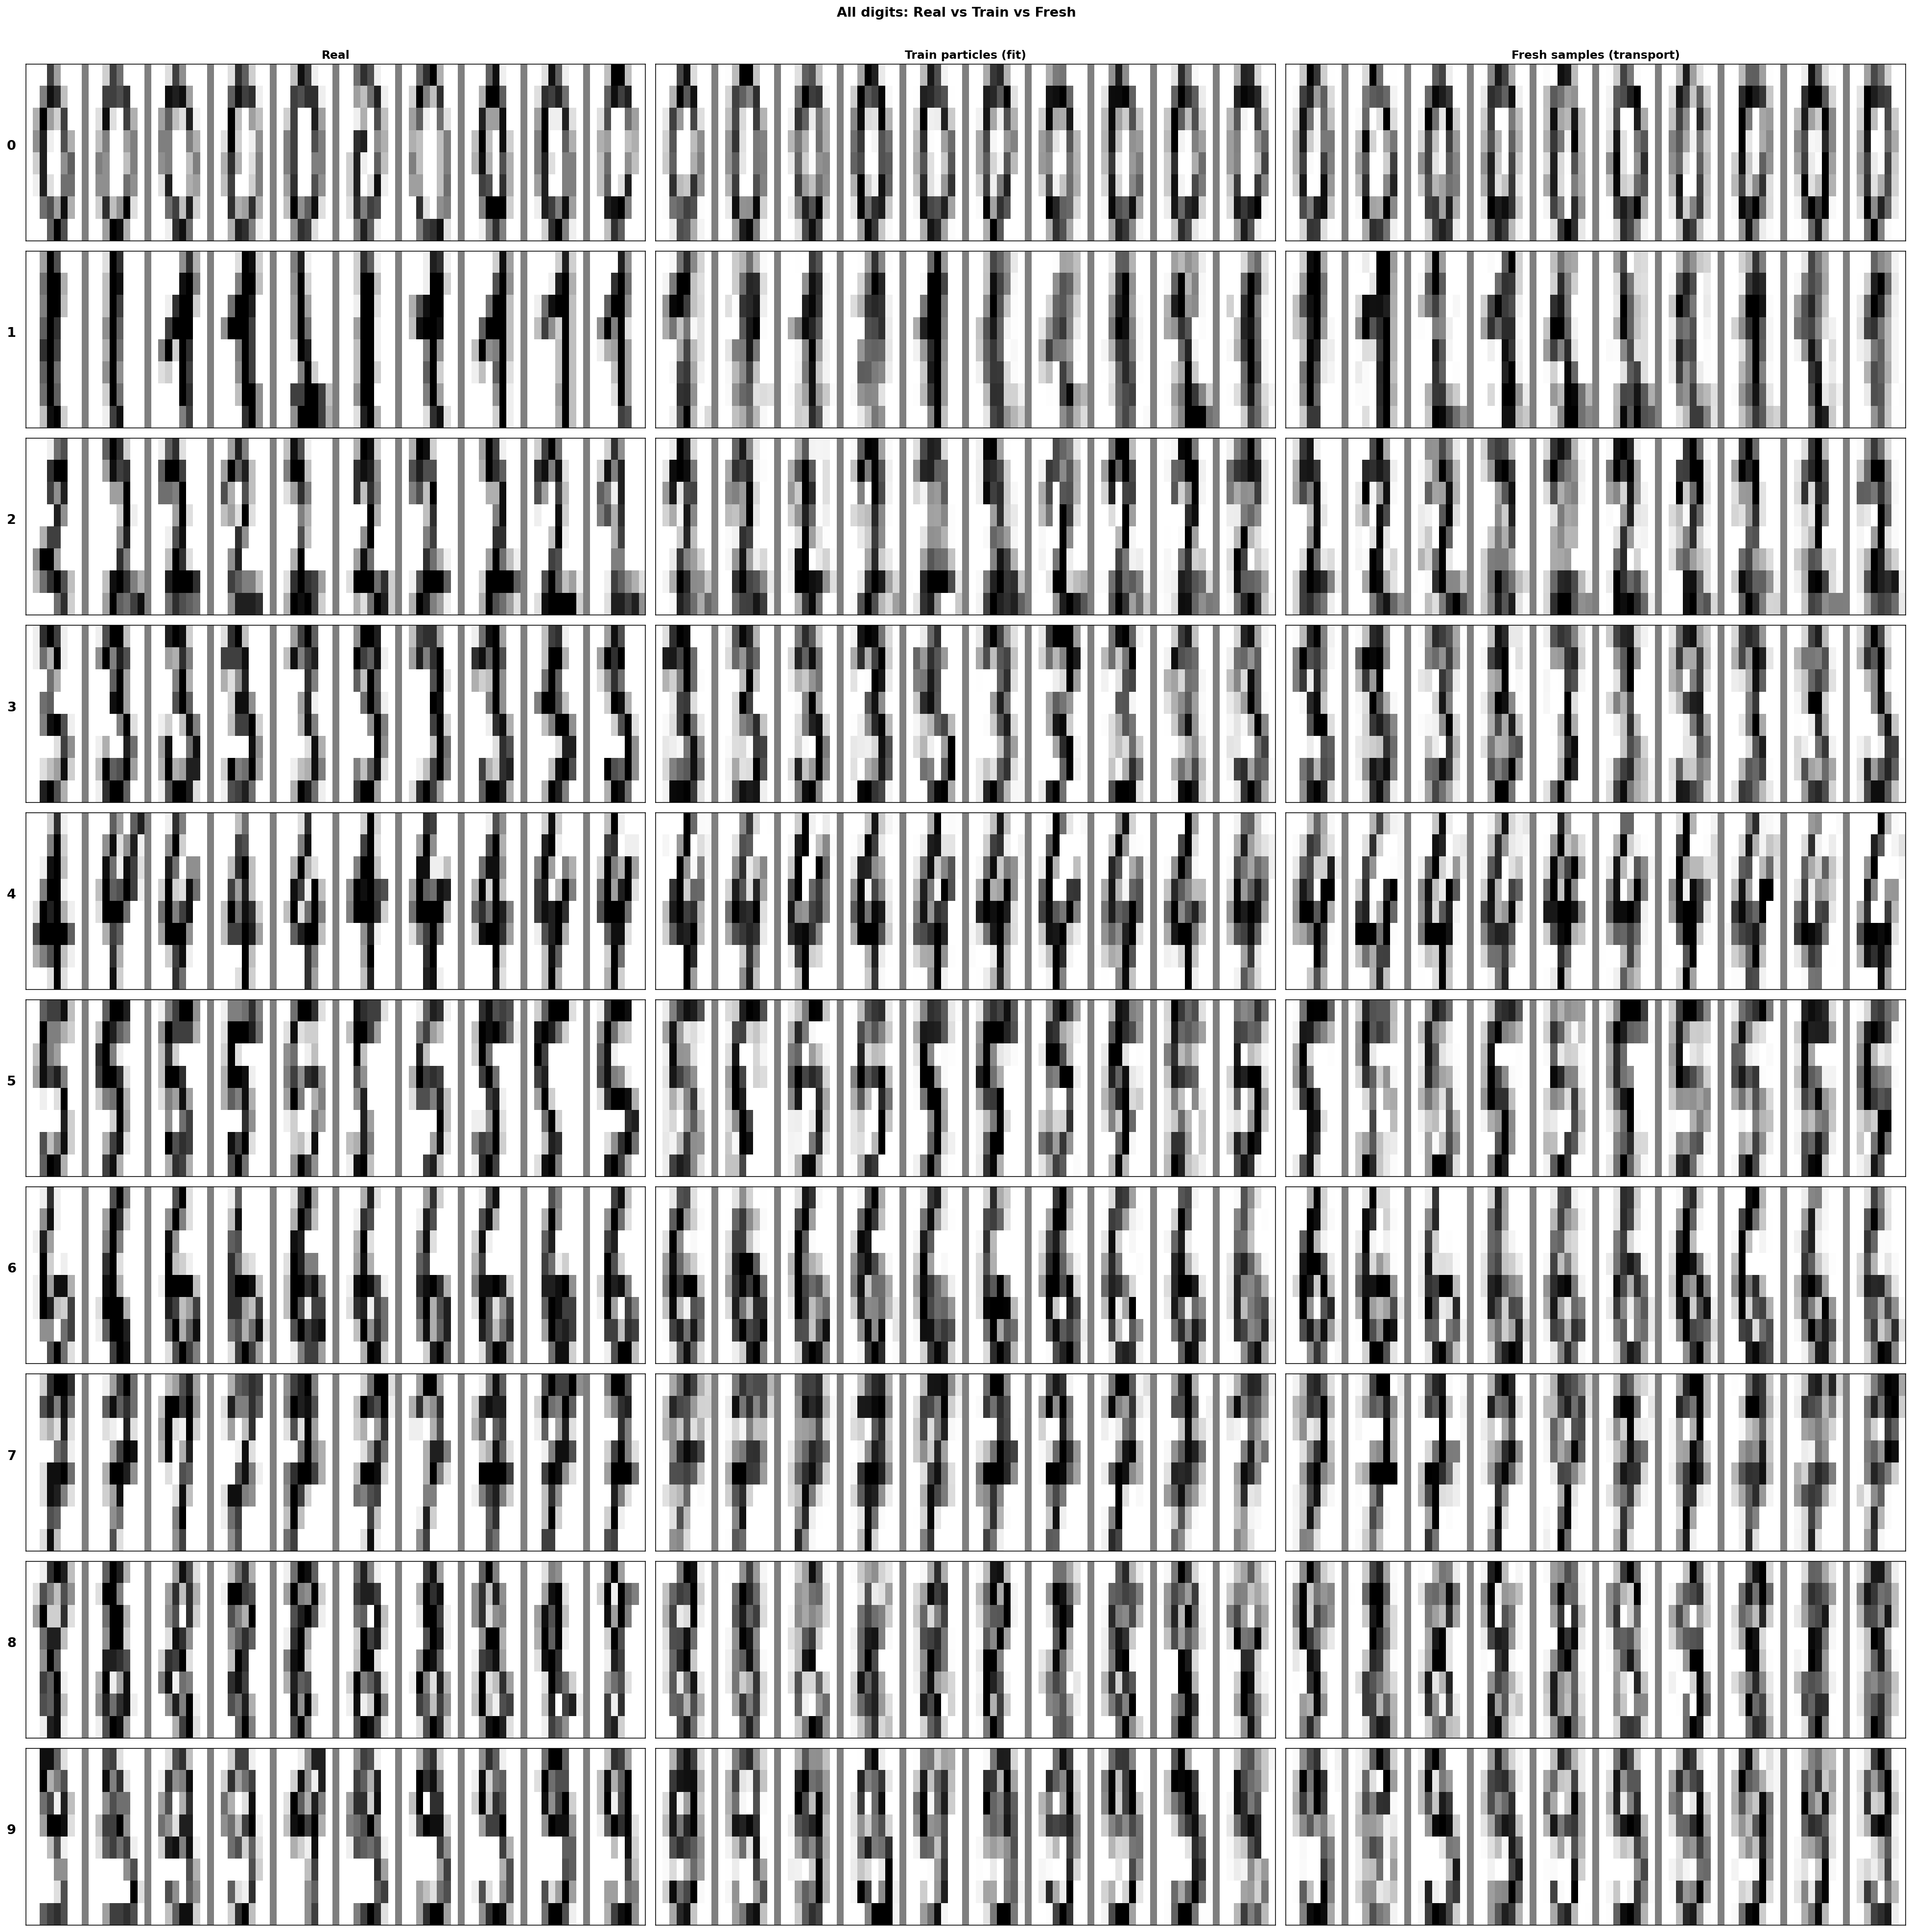

In [28]:
fig, axes = plt.subplots(10, 3, figsize=(28, 28))
for digit in range(10):
    r = results[digit]
    show_digits(r['real'], n=10, ax=axes[digit,0])
    show_digits(r['train_pixels'], n=10, ax=axes[digit,1])
    show_digits(r['fresh_pixels'], n=10, ax=axes[digit,2])
    axes[digit,0].set_ylabel(f'{digit}', fontsize=14, fontweight='bold', rotation=0, labelpad=15)
    if digit==0:
        axes[digit,0].set_title('Real', fontsize=12, fontweight='bold')
        axes[digit,1].set_title('Train particles (fit)', fontsize=12, fontweight='bold')
        axes[digit,2].set_title('Fresh samples (transport)', fontsize=12, fontweight='bold')
fig.suptitle('All digits: Real vs Train vs Fresh', fontweight='bold', fontsize=14, y=1.005)
plt.tight_layout(); plt.show()

In [31]:
d_pca = 3
results = {}

for digit in range(10):
    mask = y_all == digit
    X_d = X_all[mask]
    pca = PCA(n_components=d_pca)
    X_pca = pca.fit_transform(X_d)
    scale = np.maximum(np.std(X_pca, axis=0, keepdims=True), 1e-3)
    X_pca_n = X_pca / scale
    idx = np.random.permutation(len(X_d))
    n_train = int(0.8 * len(X_d))
    X_train = X_pca_n[idx[:n_train]]
    X_test  = X_pca_n[idx[n_train:]]

    n_src  = 500
    n_test = 500

    model = EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-8, K_steps=80, n_inducing=100, q=0.5, q_final=0.1)
    model.fit(np.random.randn(n_src, d_pca), X_train,
              n_iterations=1, verbose=False)
    res = model.transport(np.random.randn(n_test, d_pca))
    sw = sliced_wasserstein1(res['particles'], X_test)

    results[digit] = {
        'sw': sw,
        'model': model,
        'res': res,
        'pca': pca,
        'scale': scale,
        'real': X_d[idx[:50]],
        'train_pixels': np.clip(pca.inverse_transform(
            model._fit_result['particles'] * scale), 0, 1),
        'fresh_pixels': np.clip(pca.inverse_transform(
            res['particles'] * scale), 0, 1),
    }
    print(f"Digit {digit}: SW1={sw:.3f}")

Digit 0: SW1=0.145
Digit 1: SW1=0.233
Digit 2: SW1=0.296
Digit 3: SW1=0.270
Digit 4: SW1=0.177
Digit 5: SW1=0.266
Digit 6: SW1=0.299
Digit 7: SW1=0.191
Digit 8: SW1=0.247
Digit 9: SW1=0.235


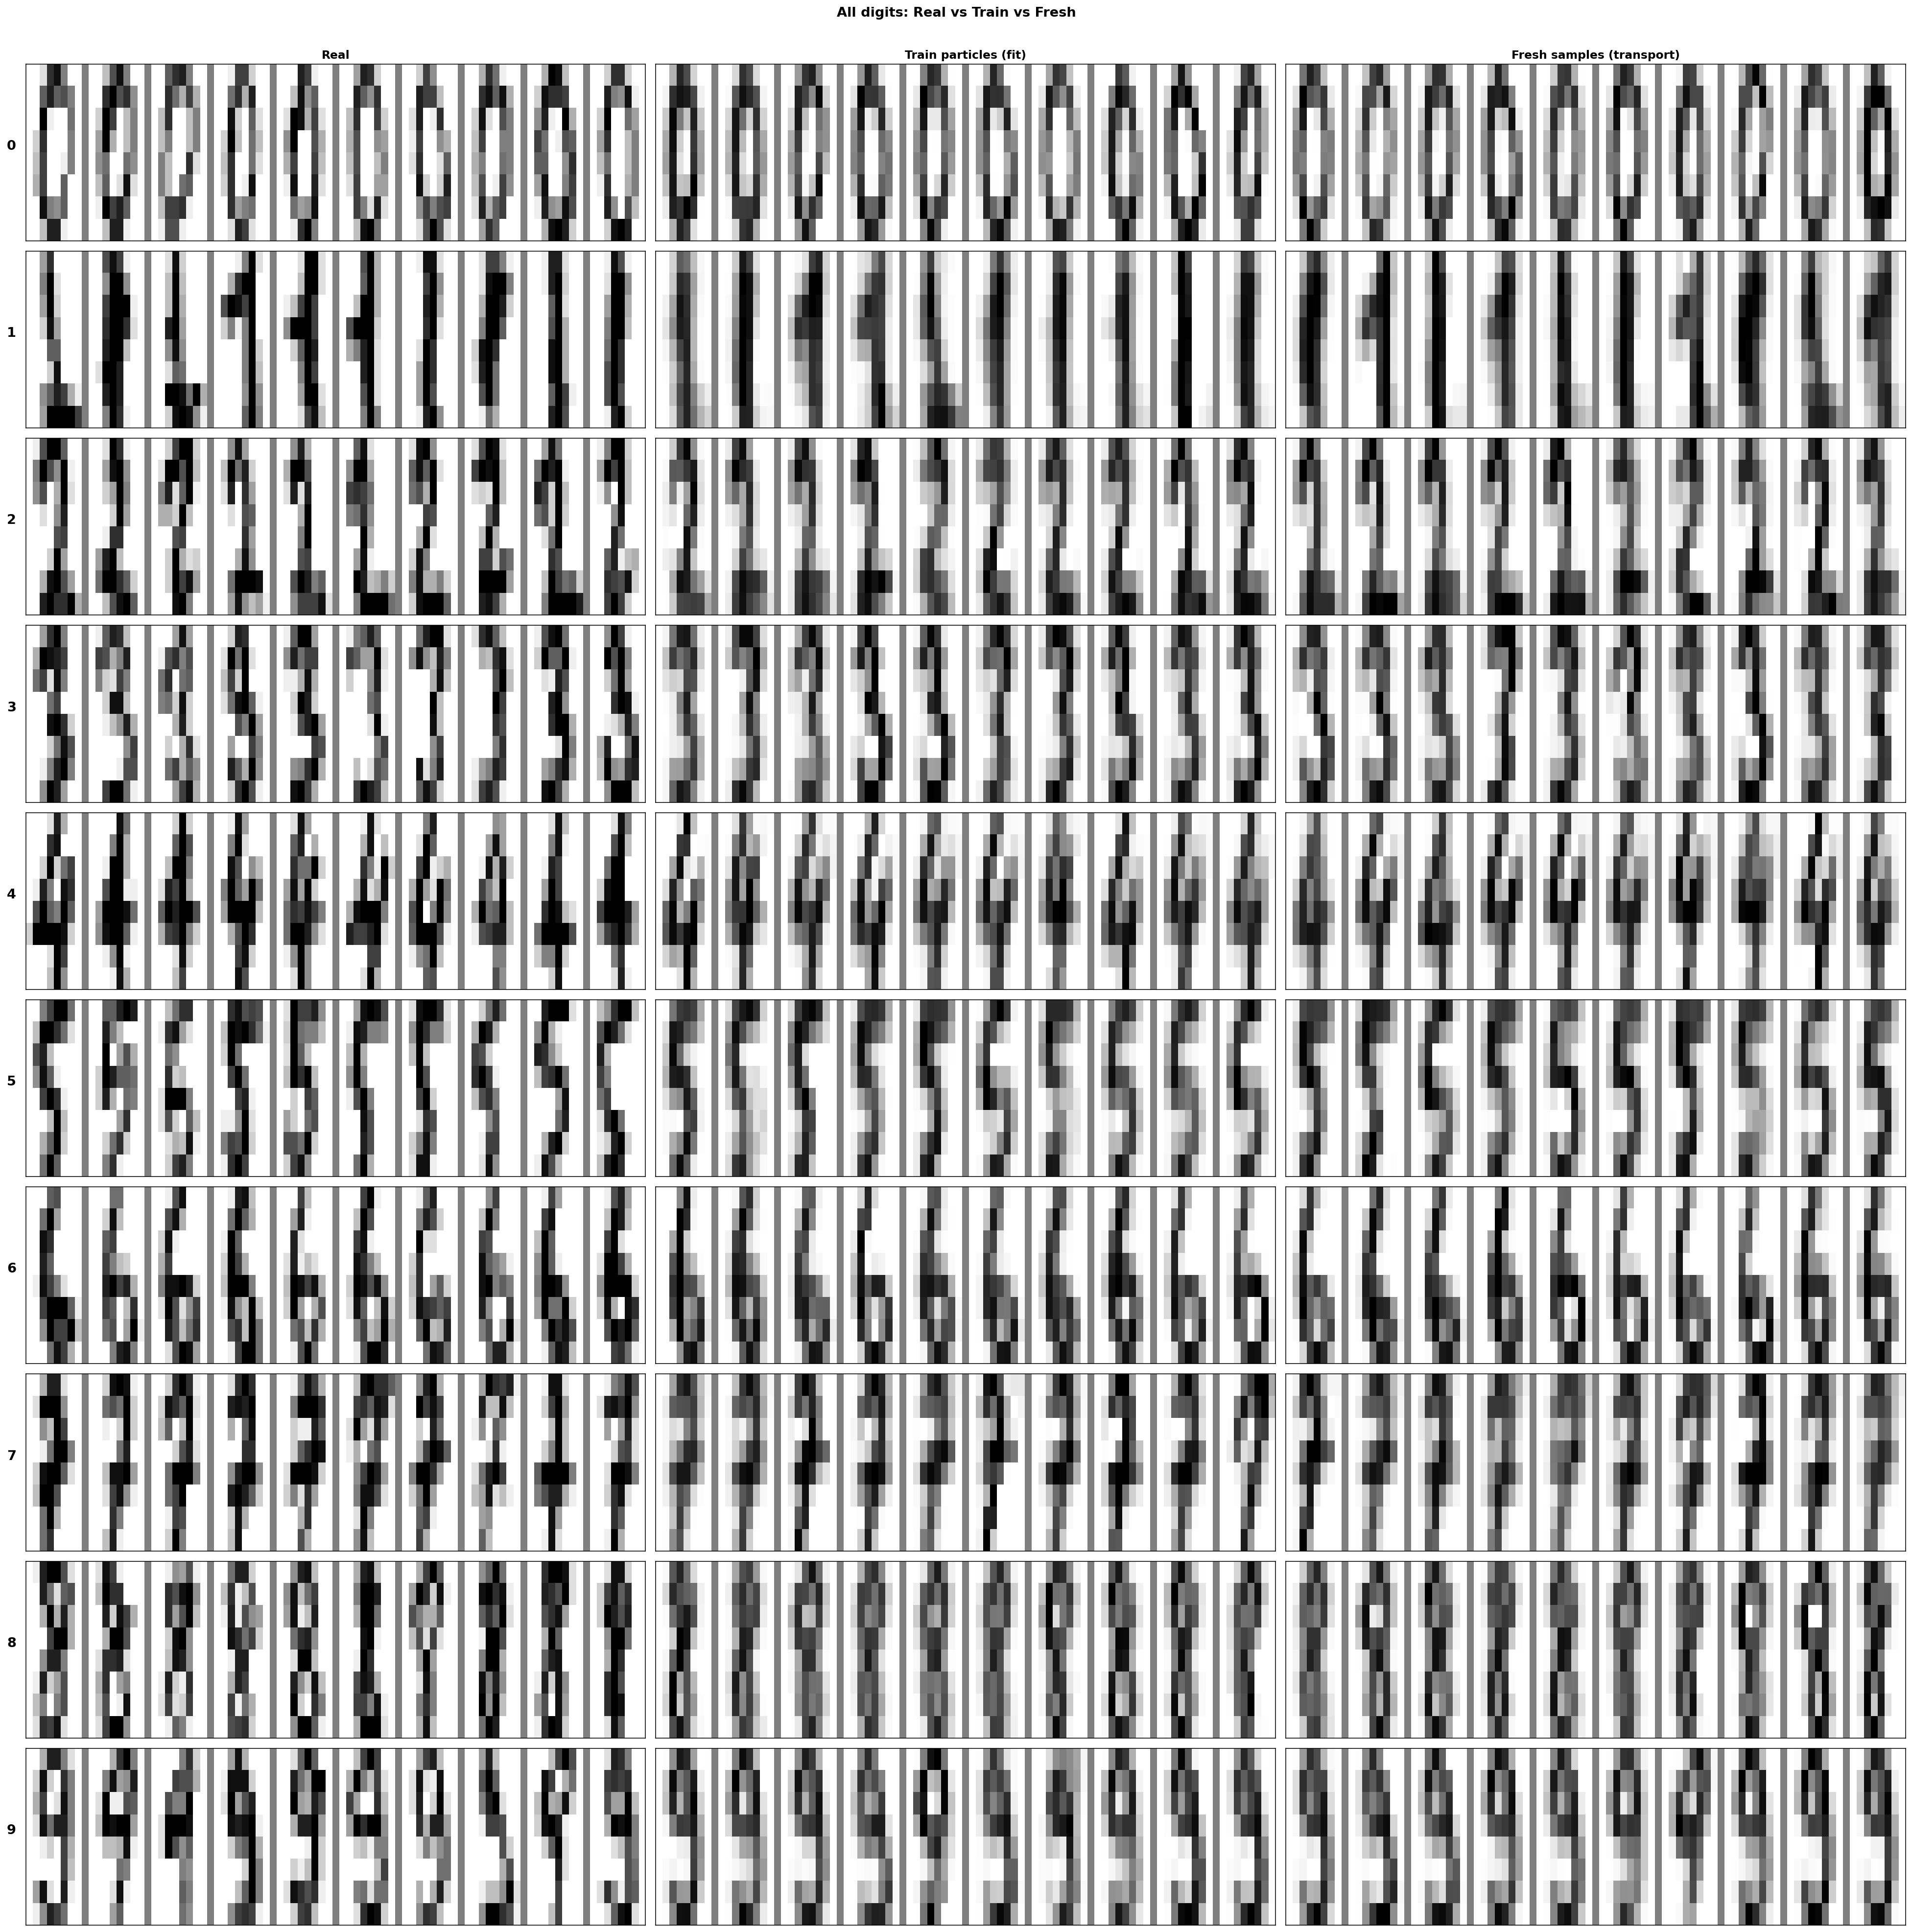

In [32]:
fig, axes = plt.subplots(10, 3, figsize=(28, 28))
for digit in range(10):
    r = results[digit]
    show_digits(r['real'], n=10, ax=axes[digit,0])
    show_digits(r['train_pixels'], n=10, ax=axes[digit,1])
    show_digits(r['fresh_pixels'], n=10, ax=axes[digit,2])
    axes[digit,0].set_ylabel(f'{digit}', fontsize=14, fontweight='bold', rotation=0, labelpad=15)
    if digit==0:
        axes[digit,0].set_title('Real', fontsize=12, fontweight='bold')
        axes[digit,1].set_title('Train particles (fit)', fontsize=12, fontweight='bold')
        axes[digit,2].set_title('Fresh samples (transport)', fontsize=12, fontweight='bold')
fig.suptitle('All digits: Real vs Train vs Fresh', fontweight='bold', fontsize=14, y=1.005)
plt.tight_layout(); plt.show()

---
## 2. Unconditional: single model, all digits

In [10]:
# PCA on ALL digits together
d_pca = 12
pca_all = PCA(n_components=d_pca)
X_pca_all = pca_all.fit_transform(X_all)
scale_all = np.maximum(np.std(X_pca_all, axis=0, keepdims=True), 1e-3)
X_pca_n_all = X_pca_all / scale_all

idx_all = np.random.permutation(len(X_all))
X_train_all = X_pca_n_all[idx_all[:1400]]
X_test_all = X_pca_n_all[idx_all[1400:]]

print(f'PCA: 64d -> {d_pca}d, explained variance: {pca_all.explained_variance_ratio_.sum():.3f}')
print(f'Train: {len(X_train_all)}, Test: {len(X_test_all)}')

PCA: 64d -> 12d, explained variance: 0.785
Train: 1400, Test: 397


In [16]:
model_all = EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-8, K_steps=80, n_inducing=100, q=0.5, q_final=0.1)
print('FIT:')
model_all.fit(np.random.randn(1000, d_pca), X_train_all, n_iterations=8)

print('\nTRANSPORT:')
X0_fresh = np.random.randn(1000, d_pca)
res_all = model_all.transport(X0_fresh, verbose=True)

FIT:
  Iter 1: lift_ratio=0.278,  gamma=0.01000,  q=0.500,  sigma=4.822,  M=100
  Iter 2: lift_ratio=0.173,  gamma=0.00857,  q=0.443,  sigma=4.702,  M=100
  Iter 3: lift_ratio=0.164,  gamma=0.00714,  q=0.386,  sigma=4.597,  M=100
  Iter 4: lift_ratio=0.164,  gamma=0.00571,  q=0.329,  sigma=4.474,  M=100
  Iter 5: lift_ratio=0.154,  gamma=0.00429,  q=0.271,  sigma=4.335,  M=100
  Iter 6: lift_ratio=0.152,  gamma=0.00286,  q=0.214,  sigma=4.168,  M=100
  Iter 7: lift_ratio=0.138,  gamma=0.00143,  q=0.157,  sigma=3.962,  M=100
  Iter 8: lift_ratio=0.120,  gamma=0.00000,  q=0.100,  sigma=3.675,  M=100

TRANSPORT:
  Iter 1: lift_ratio=0.273
  Iter 2: lift_ratio=0.172
  Iter 3: lift_ratio=0.161
  Iter 4: lift_ratio=0.159
  Iter 5: lift_ratio=0.150
  Iter 6: lift_ratio=0.148
  Iter 7: lift_ratio=0.131
  Iter 8: lift_ratio=0.117


In [17]:
# Reconstruct
gen_pixels = np.clip(pca_all.inverse_transform(res_all['particles'] * scale_all), 0, 1)

# Classify with KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_pca_n_all, y_all)
gen_labels = knn.predict(res_all['particles'])

print('Generated digit distribution:')
for d in range(10):
    n_d = np.sum(gen_labels==d)
    print(f'  Digit {d}: {n_d}/200 ({n_d/2:.0f}%)')

Generated digit distribution:
  Digit 0: 99/200 (50%)
  Digit 1: 85/200 (42%)
  Digit 2: 107/200 (54%)
  Digit 3: 106/200 (53%)
  Digit 4: 101/200 (50%)
  Digit 5: 97/200 (48%)
  Digit 6: 119/200 (60%)
  Digit 7: 115/200 (58%)
  Digit 8: 78/200 (39%)
  Digit 9: 93/200 (46%)


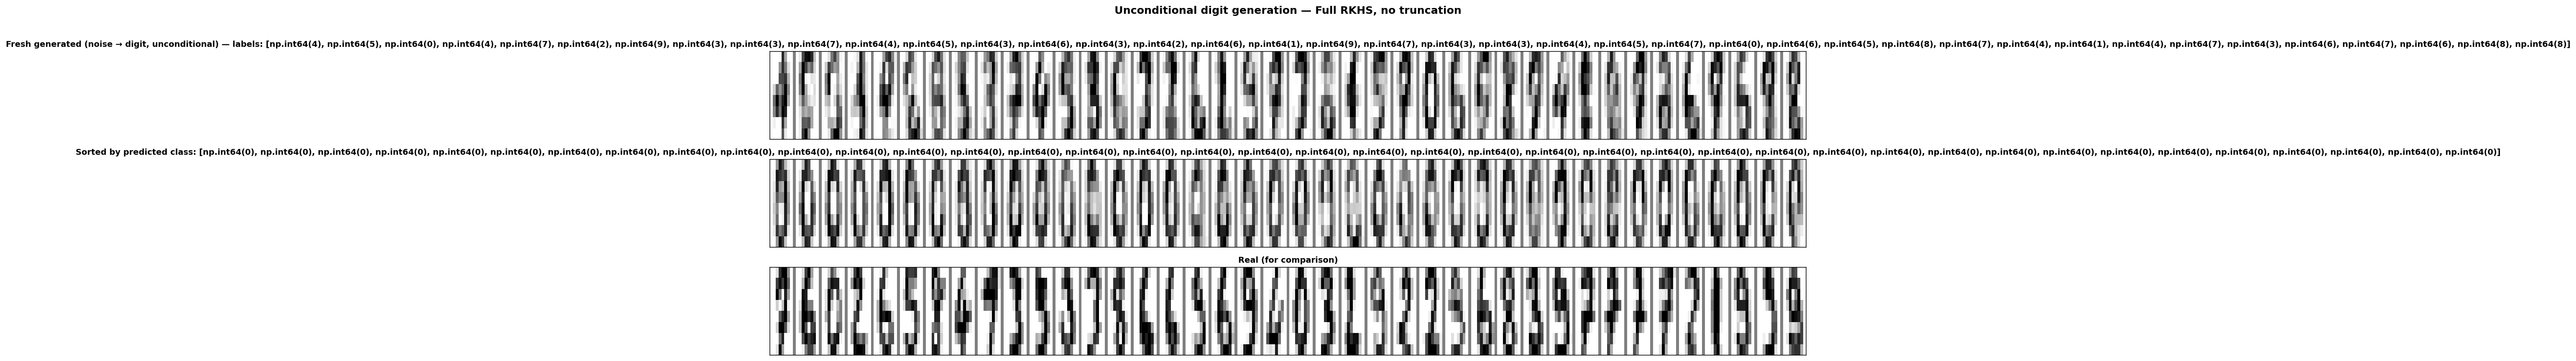

In [18]:
# Big display: generated samples
n_show = 40
fig, axes = plt.subplots(3, 1, figsize=(18, 6))

# Row 0: fresh generated
show_digits(gen_pixels, n=n_show, ax=axes[0],
            title=f'Fresh generated (noise → digit, unconditional) — labels: {list(gen_labels[:n_show])}')

# Row 1: sorted by class
sorted_idx = np.argsort(gen_labels)
show_digits(gen_pixels[sorted_idx], n=n_show, ax=axes[1],
            title=f'Sorted by predicted class: {list(gen_labels[sorted_idx[:n_show]])}')

# Row 2: real for comparison
real_show = X_all[np.random.choice(len(X_all), n_show, replace=False)]
show_digits(real_show, n=n_show, ax=axes[2], title='Real (for comparison)')

fig.suptitle('Unconditional digit generation — Full RKHS, no truncation', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

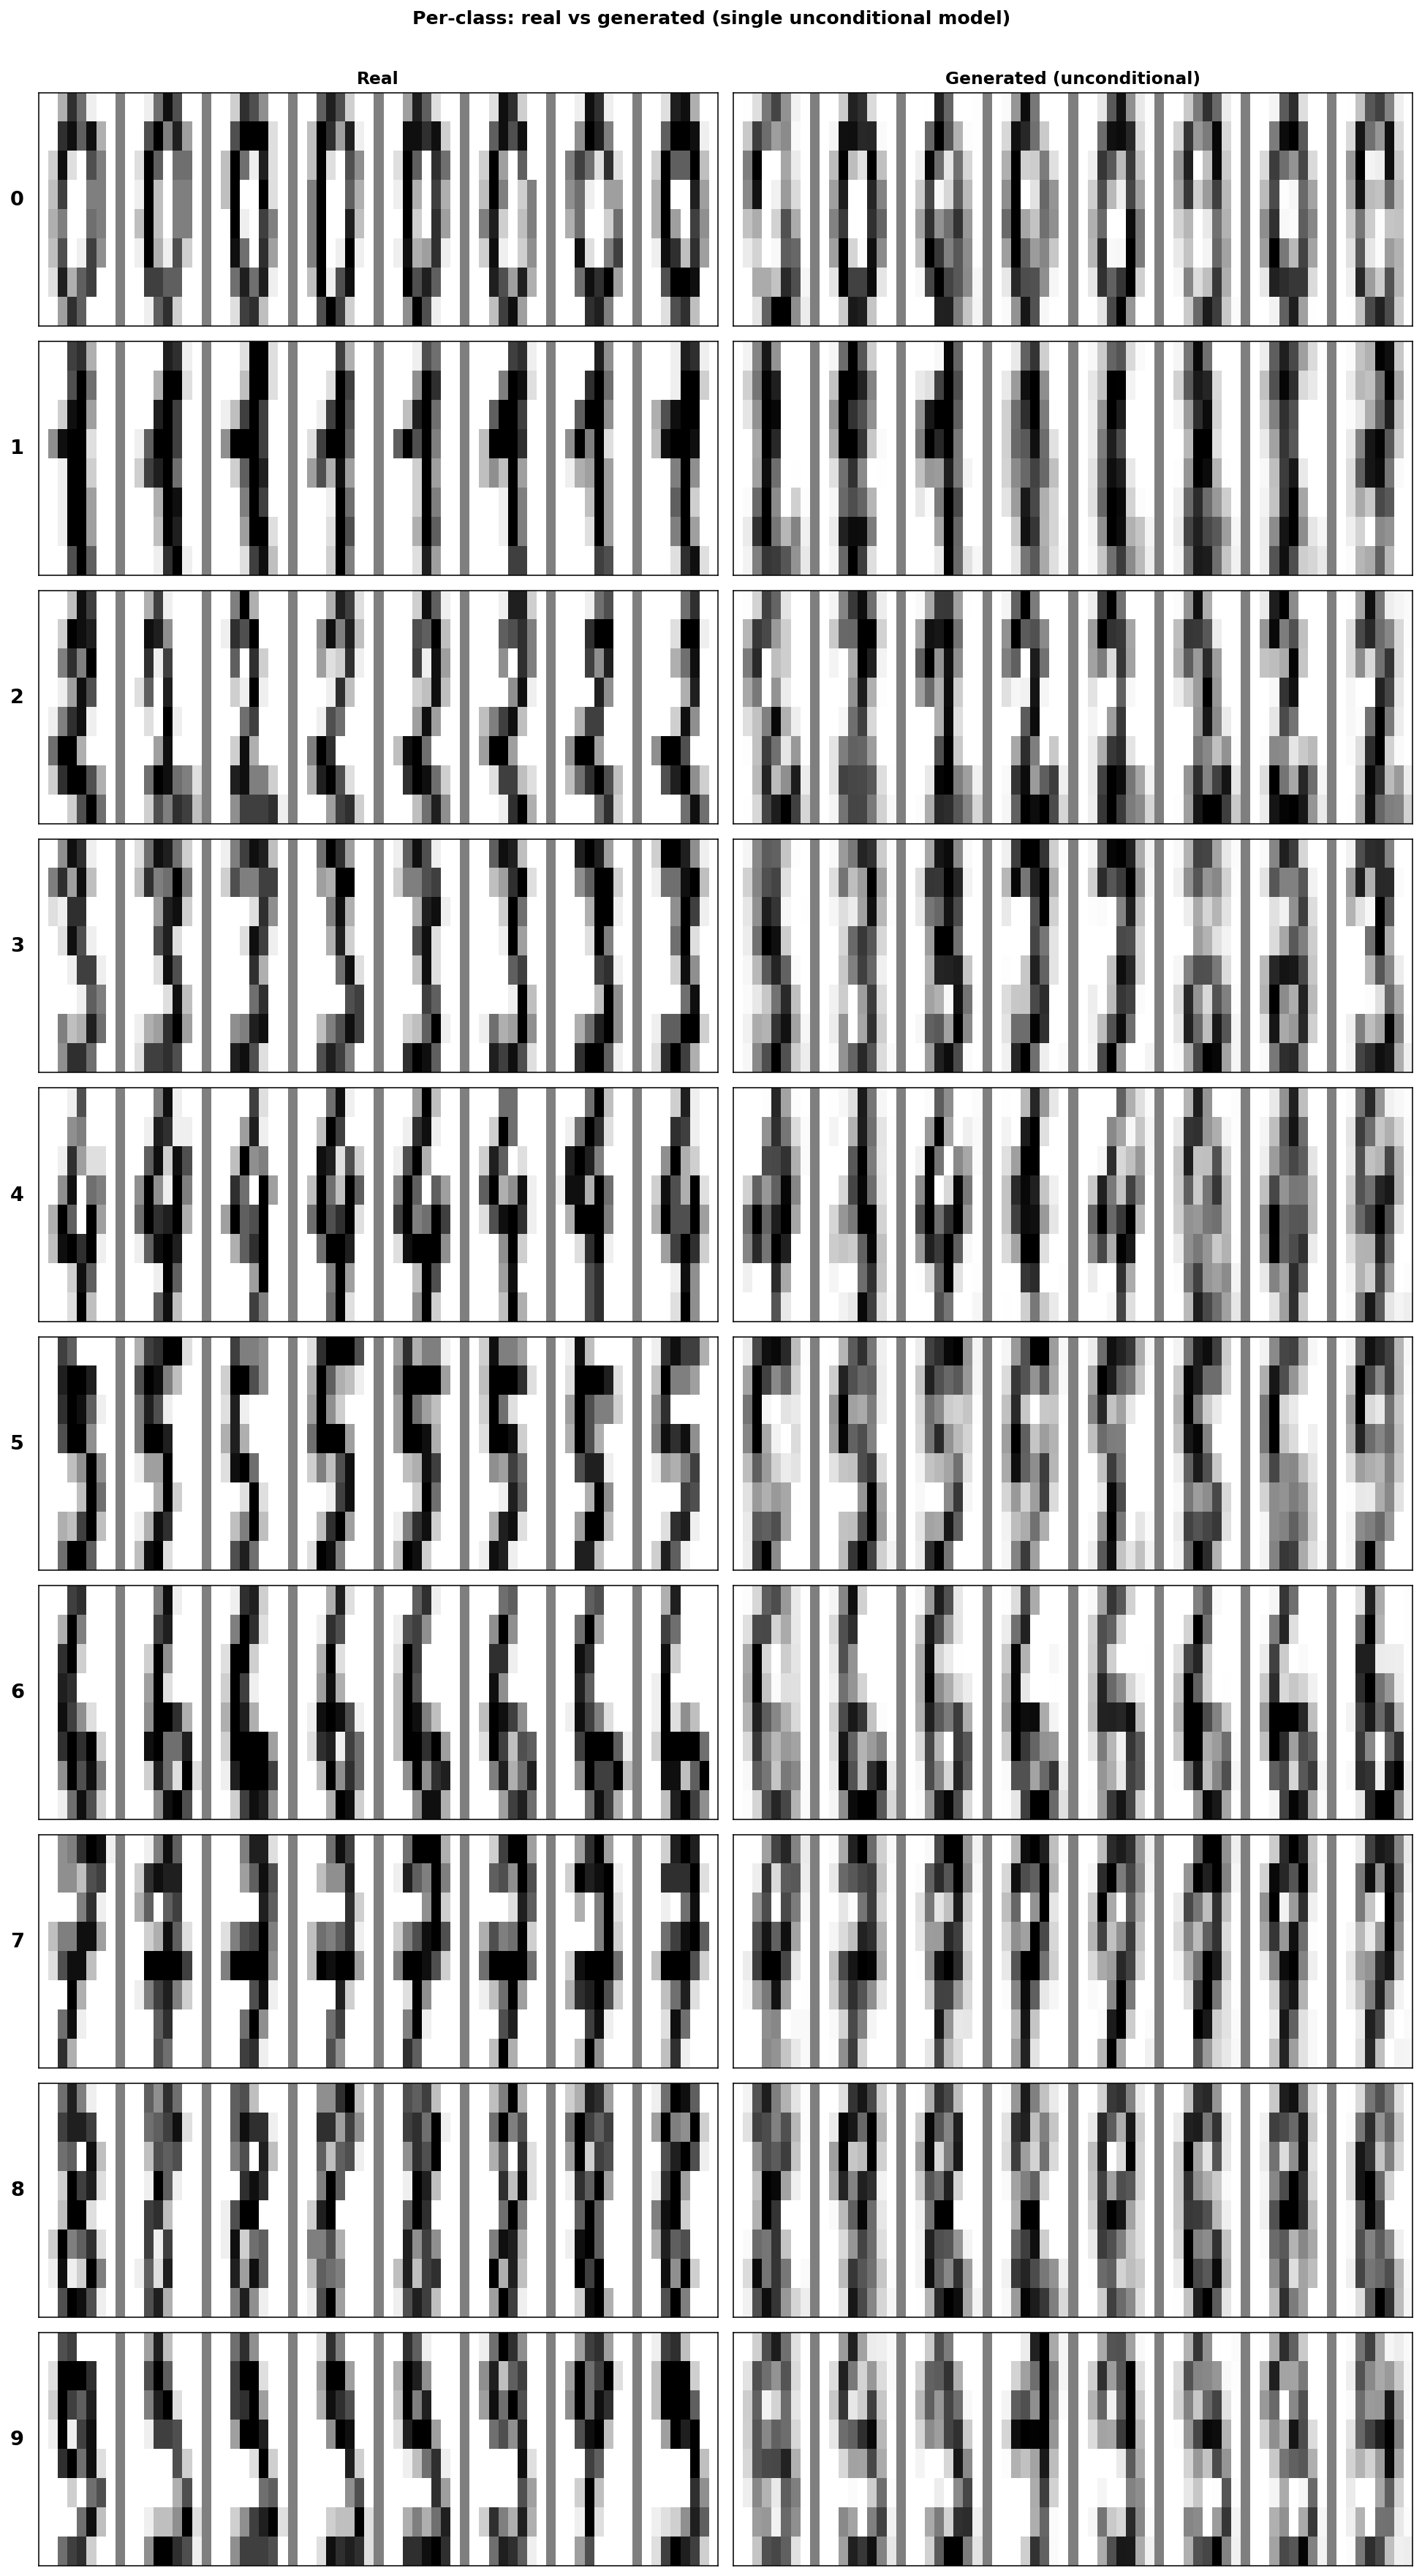

In [19]:
# Per-class: real vs generated
fig, axes = plt.subplots(10, 2, figsize=(14, 25))
for digit in range(10):
    show_digits(X_all[y_all==digit][:8], n=8, ax=axes[digit,0])
    gen_d = gen_pixels[gen_labels==digit][:8]
    show_digits(gen_d, n=8, ax=axes[digit,1])
    axes[digit,0].set_ylabel(f'{digit}', fontsize=14, fontweight='bold', rotation=0, labelpad=15)
    if digit==0:
        axes[digit,0].set_title('Real', fontsize=12, fontweight='bold')
        axes[digit,1].set_title('Generated (unconditional)', fontsize=12, fontweight='bold')
fig.suptitle('Per-class: real vs generated (single unconditional model)', fontweight='bold', fontsize=13, y=1.005)
plt.tight_layout(); plt.show()

---
## 3. Watch digits form: evolution of fresh samples

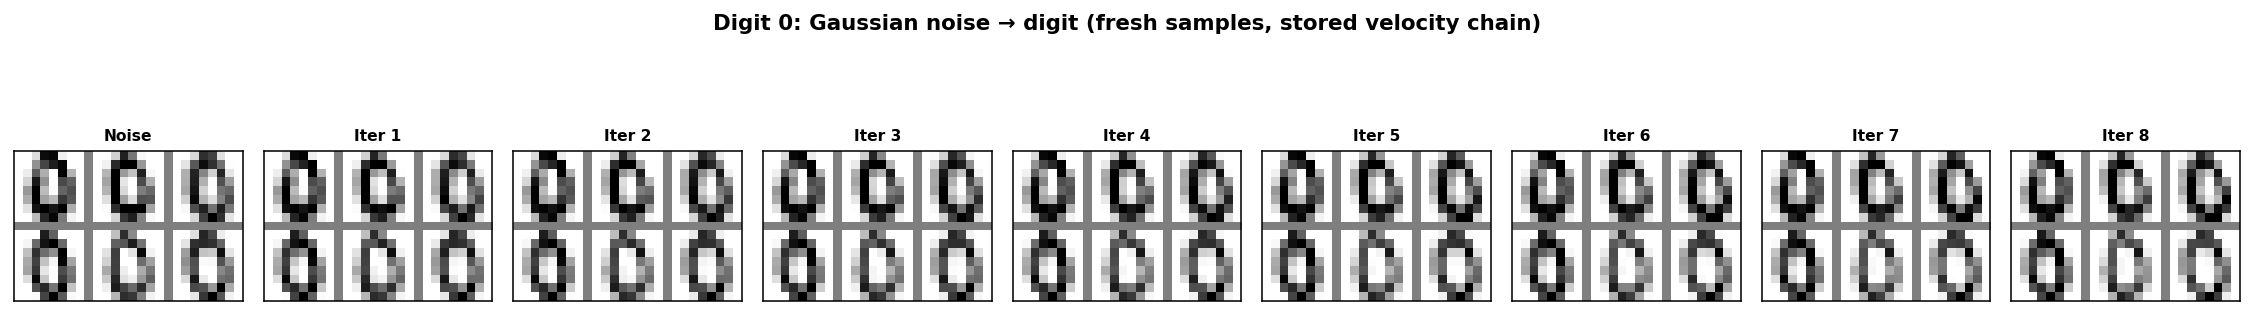

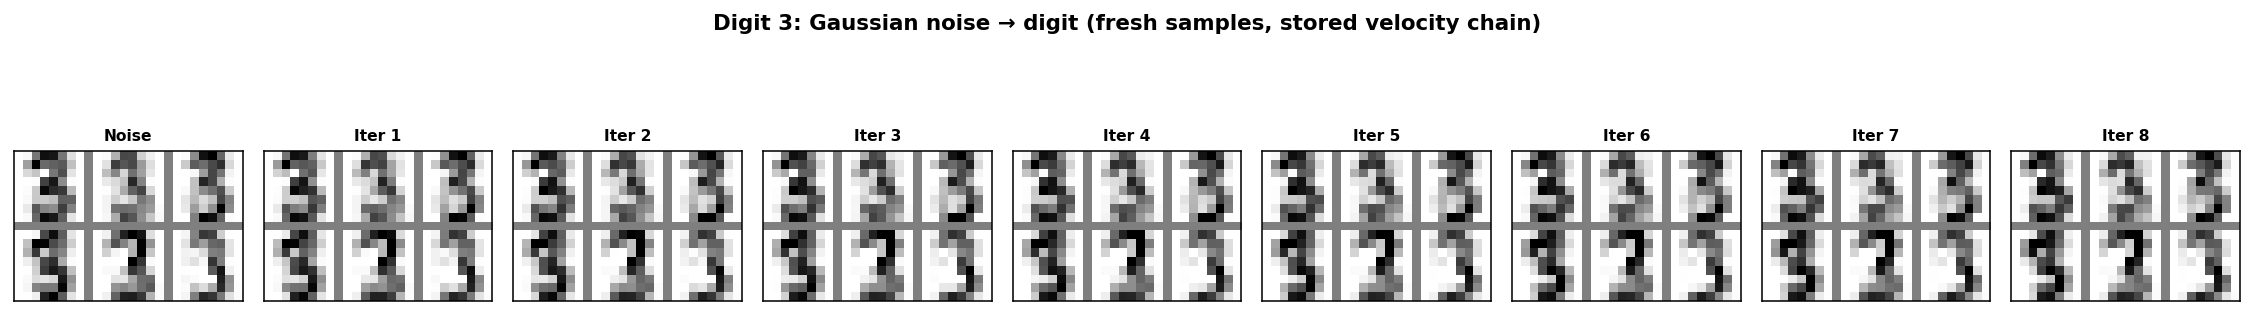

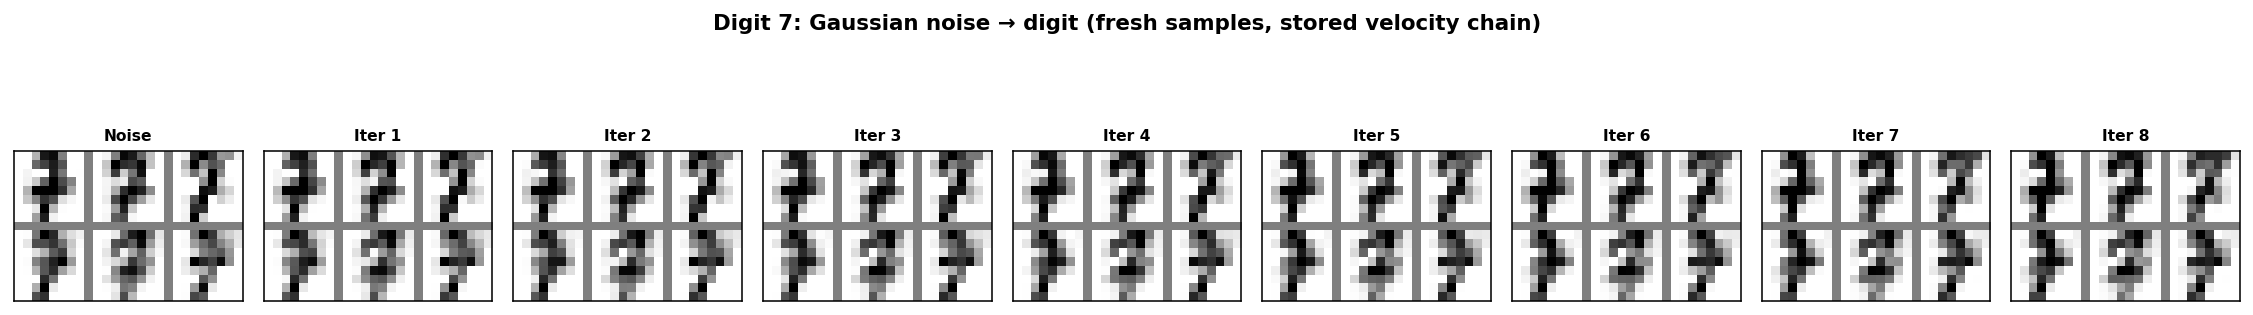

In [14]:
# Evolution: watch fresh noise become digits
for digit in [0, 3, 7]:
    r = results[digit]
    X0_viz = np.random.randn(6, r['pca'].n_components_)
    res_viz = r['model'].transport(X0_viz)
    n_it = len(res_viz['snapshots'])
    
    fig, axes = plt.subplots(1, n_it, figsize=(n_it*1.8, 2.5))
    for it in range(n_it):
        snap = res_viz['snapshots'][it]
        pixels = np.clip(r['pca'].inverse_transform(snap * r['scale']), 0, 1)
        grid = np.ones((8*2+1, 8*3+2)) * 0.5
        for j in range(min(6, len(pixels))):
            row, col = j//3, j%3
            grid[row*9:row*9+8, col*9:col*9+8] = pixels[j].reshape(8,8)
        ax = axes[it]
        ax.imshow(grid, cmap='gray_r', interpolation='nearest', vmin=0, vmax=1)
        ax.set_title('Noise' if it==0 else f'Iter {it}', fontsize=8, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f'Digit {digit}: Gaussian noise → digit (fresh samples, stored velocity chain)',
                 fontweight='bold', fontsize=11, y=1.05)
    plt.tight_layout(); plt.show()

In [15]:
# Summary stats
print('Per-digit SW1:')
for d in range(10): print(f'  Digit {d}: {results[d]["sw"]:.3f} (sigma={results[d]["sigma"]})')
print(f'\nMean SW1: {np.mean([results[d]["sw"] for d in range(10)]):.3f}')
print(f'\nUnconditional SW1: {sliced_wasserstein1(res_all["particles"], X_test_all):.3f}')

Per-digit SW1:
  Digit 0: 0.347 (sigma=1.5)
  Digit 1: 0.319 (sigma=1.5)
  Digit 2: 0.304 (sigma=1.5)
  Digit 3: 0.297 (sigma=1.5)
  Digit 4: 0.304 (sigma=1.5)
  Digit 5: 0.350 (sigma=1.5)
  Digit 6: 0.359 (sigma=1.5)
  Digit 7: 0.369 (sigma=1.5)
  Digit 8: 0.291 (sigma=1.5)
  Digit 9: 0.350 (sigma=1.5)

Mean SW1: 0.329

Unconditional SW1: 0.247
